1. Download and load the Student Performance dataset.


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [24]:
df = pd.read_csv("student-mat.csv", sep=";")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (395, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


- The Student Performance dataset contains 395 student records and 33 attributes
- Each row represents one student, and each column represents a feature such as demographic details, study habits, family background, and academic performance

2. Perform data preprocessing, including handling missing values (if any), encoding categorical variables, and feature scaling.

In [25]:
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int64
 3   address     395 non-null    str  
 4   famsize     395 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 non-null    str  
 11  guardian    395 non-null    str  
 12  traveltime  395 non-null    int64
 13  studytime   395 non-null    int64
 14  failures    395 non-null    int64
 15  schoolsup   395 non-null    str  
 16  famsup      395 non-null    str  
 17  paid        395 non-null    str  
 18  activities  395 non-null    str  
 19  nursery     395 non-null    str  
 20  higher      395 non-null    str  
 21  inte

- The dataset contains 395 entries.
- There are no missing values in any column

In [40]:
# one hot encode all categorical columns
df = pd.get_dummies(df, drop_first=True)
print(df.head())
print(df.shape)
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

print(df.dtypes)

   age  Medu  Fedu  traveltime  studytime  failures  famrel  freetime  goout  \
0   18     4     4           2          2         0       4         3      4   
1   17     1     1           1          2         0       5         3      3   
2   15     1     1           1          2         3       4         3      2   
3   15     4     2           1          3         0       3         2      2   
4   16     3     3           1          2         0       4         3      2   

   Dalc  ...  guardian_mother  guardian_other  schoolsup_yes  famsup_yes  \
0     1  ...             True           False           True       False   
1     1  ...            False           False          False        True   
2     2  ...             True           False           True       False   
3     1  ...             True           False          False        True   
4     1  ...            False           False          False        True   

   paid_yes  activities_yes  nursery_yes  higher_yes  internet

- All categorical variables have been converted into numerical variables using ohc

3. Select appropriate input features and the target variable.


In [41]:
#select features and target
X = df.drop("G3", axis=1)
y = df["G3"]

4. Split the dataset into training and testing sets.


In [43]:
#splitting 
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [44]:
print(df.dtypes)

age                  int64
Medu                 int64
Fedu                 int64
traveltime           int64
studytime            int64
failures             int64
famrel               int64
freetime             int64
goout                int64
Dalc                 int64
Walc                 int64
health               int64
absences             int64
G1                   int64
G2                   int64
G3                   int64
school_MS            int64
sex_M                int64
address_U            int64
famsize_LE3          int64
Pstatus_T            int64
Mjob_health          int64
Mjob_other           int64
Mjob_services        int64
Mjob_teacher         int64
Fjob_health          int64
Fjob_other           int64
Fjob_services        int64
Fjob_teacher         int64
reason_home          int64
reason_other         int64
reason_reputation    int64
guardian_mother      int64
guardian_other       int64
schoolsup_yes        int64
famsup_yes           int64
paid_yes             int64
a

In [45]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

y_train = y_train.values
y_test = y_test.values

In [48]:
#initializing the parameters
learning_rate = 0.01
iterations = 1000

m = X_train.shape[0]
n = X_train.shape[1]

weights = np.zeros(n)
bias = 0

loss_history = []

5. Implement Linear Regression using the Gradient Descent algorithm.


In [49]:
#gd algo
for i in range(iterations):

    # Prediction
    y_pred = np.dot(X_train, weights) + bias

    # Error
    error = y_pred - y_train

    # Cost Function
    loss = np.mean(error ** 2)

    loss_history.append(loss)

    # Gradients
    dw = (2 / m) * np.dot(X_train.T, error)
    db = (2 / m) * np.sum(error)

    # Update Parameters
    weights = weights - learning_rate * dw
    bias = bias - learning_rate * db

print("Training Completed")

Training Completed


7. Plot the loss (cost) versus the number of iterations.


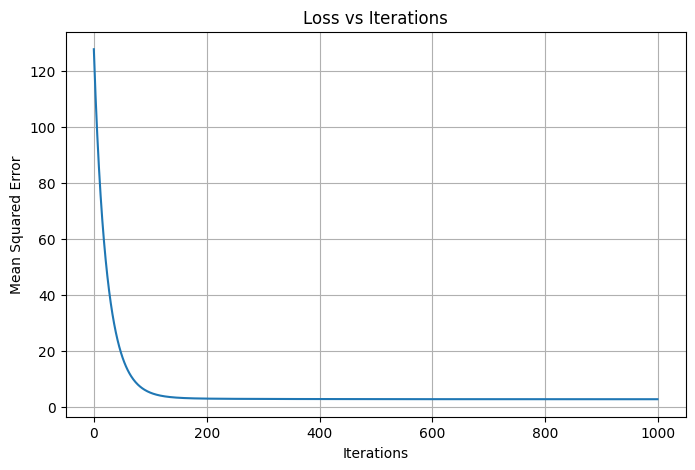

In [50]:
#plot loss v siterations
plt.figure(figsize=(8,5))
plt.plot(loss_history)
plt.title("Loss vs Iterations")
plt.xlabel("Iterations")
plt.ylabel("Mean Squared Error")
plt.grid(True)
plt.show()

- The graph shows that the loss decreases steadily as the number of iterations increases.
- Initially, the error is high because the model parameters are randomly initialized.
- As Gradient Descent updates the parameters, the loss gradually decreases and eventually stabilizes.
- The stable curve indicates that the algorithm has converged to an optimal solution.

8. Evaluate the trained model using:
- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score


In [51]:
#predict test data
y_pred = np.dot(X_test, weights) + bias

In [52]:
#evaluating the model 
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", round(mae,3))
print("Mean Squared Error (MSE):", round(mse,3))
print("Root Mean Squared Error (RMSE):", round(rmse,3))
print("R² Score:", round(r2,3))

Mean Absolute Error (MAE): 1.656
Mean Squared Error (MSE): 5.668
Root Mean Squared Error (RMSE): 2.381
R² Score: 0.724


MAE - On average, the predicted student grade differs from the actual grade by approximately 1.66 marks.
MSE - The average squared prediction error is 5.668. Since errors are squared, larger prediction errors receive a greater penalty.
RMSE - differ from the actual grades by approximately 2.38 marks on average.
R Square - 72.4% of the variation in students' final grades.This indicates a good regression model with satisfactory predictive performance.

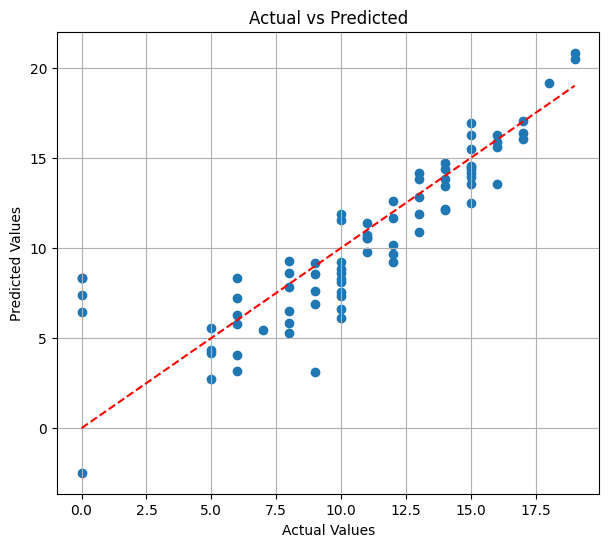

In [53]:
plt.figure(figsize=(7,6))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.grid(True)

plt.show()

- Each point represents one student's actual and predicted final grade.
- Most points lie close to the diagonal reference line, indicating that the predictions are close to the actual values.

6. Experiment with different learning rates and observe their effect on model convergence.


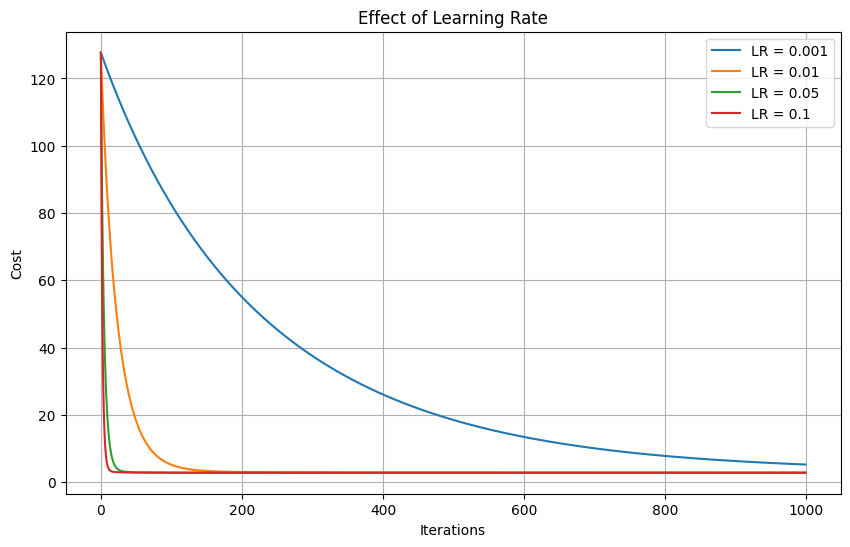

In [54]:
#different learning rates
learning_rates = [0.001, 0.01, 0.05, 0.1]

plt.figure(figsize=(10,6))

for lr in learning_rates:

    weights = np.zeros(n)
    bias = 0

    costs = []

    for i in range(iterations):

        prediction = np.dot(X_train, weights) + bias

        error = prediction - y_train

        cost = np.mean(error ** 2)

        costs.append(cost)

        dw = (2 / m) * np.dot(X_train.T, error)
        db = (2 / m) * np.sum(error)

        weights -= lr * dw
        bias -= lr * db

    plt.plot(costs, label=f"LR = {lr}")

plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Effect of Learning Rate")
plt.legend()
plt.grid(True)

plt.show()

- A learning rate of 0.001 converges slowly because parameter updates are very small.
- Learning rates of 0.01, 0.05, and 0.1 converge much faster.

9. Interpret the results and comment on the convergence behavior and prediction performance of the model.


In [55]:
#comparing evaluation metrics
results = []

learning_rates = [0.001, 0.01, 0.05, 0.1]

for lr in learning_rates:

    weights = np.zeros(n)
    bias = 0

    for i in range(iterations):

        prediction = np.dot(X_train, weights) + bias

        error = prediction - y_train

        dw = (2 / m) * np.dot(X_train.T, error)
        db = (2 / m) * np.sum(error)

        weights -= lr * dw
        bias -= lr * db

    pred = np.dot(X_test, weights) + bias

    mae = mean_absolute_error(y_test, pred)
    mse = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, pred)

    results.append([lr, mae, mse, rmse, r2])

results_df = pd.DataFrame(
    results,
    columns=["Learning Rate", "MAE", "MSE", "RMSE", "R² Score"]
)

print(results_df)

   Learning Rate       MAE       MSE      RMSE  R² Score
0          0.001  2.463606  8.532703  2.921079  0.583873
1          0.010  1.655742  5.667602  2.380673  0.723600
2          0.050  1.646677  5.656668  2.378375  0.724133
3          0.100  1.646666  5.656643  2.378370  0.724134


- A learning rate of 0.001 resulted in the highest prediction error because the model converged too slowly within the given number of iterations.
- Learning rates of 0.01, 0.05, and 0.10 achieved very similar performance with lower error values and higher R² scores.
- Among the tested values, 0.05 and 0.10 provided the best performance, with an R² score of approximately 0.724.

In [56]:
#sample pred
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": np.round(y_pred,2)
})

comparison.head(10)

,Actual,Predicted
0,10,6.12
1,12,11.67
2,5,2.72
3,10,8.82
4,9,8.56
5,13,11.88
6,18,19.13
7,6,7.21
8,0,7.38
9,14,12.18


- Most predicted values are close to the actual values